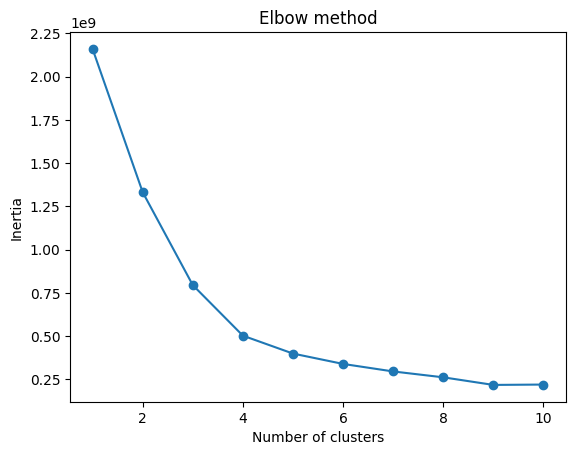

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from plyfile import PlyElement, PlyData
from sklearn.cluster import KMeans


#Import data and arrange for KMeans clustering
pdata = PlyData.read("rubiks_base.ply")
points_full = np.array(pdata['vertex'])
num_points = points_full.size
points3D = points_full[['red','green','blue']]
pointsPD = pd.DataFrame(points3D)
pointsPD.columns=range(3)



#Estimate required number of clusters
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(pointsPD)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show() 


In [2]:

kmeans = KMeans(n_clusters=7)
kmeans.fit(pointsPD)


labels = kmeans.labels_
num_points = labels.size


# Red: 255, 0, 0
# Yellow: 255, 255, 0
# Green: 0, 255, 0
# Cyan: 0, 255, 255
# Blue: 0, 0, 255
# Magenta: 255, 0, 255

#Color each point based on label assignment
for pt in range(num_points):
    if labels[pt] == 0:
        pdata['vertex']['red'][pt] = 255
        pdata['vertex']['green'][pt] = 0
        pdata['vertex']['blue'][pt] = 0
    if labels[pt] == 1:
        pdata['vertex']['red'][pt] = 255
        pdata['vertex']['green'][pt] = 255
        pdata['vertex']['blue'][pt] = 0
    if labels[pt] == 2:
        pdata['vertex']['red'][pt] = 0
        pdata['vertex']['green'][pt] = 255
        pdata['vertex']['blue'][pt] = 0
    if labels[pt] == 3:
        pdata['vertex']['red'][pt] = 0
        pdata['vertex']['green'][pt] = 255
        pdata['vertex']['blue'][pt] = 255
    if labels[pt] == 4:
        pdata['vertex']['red'][pt] = 0
        pdata['vertex']['green'][pt] = 0
        pdata['vertex']['blue'][pt] = 255
    if labels[pt] == 5:
        pdata['vertex']['red'][pt] = 255
        pdata['vertex']['green'][pt] = 0
        pdata['vertex']['blue'][pt] = 255
    if labels[pt] == 6:
        pdata['vertex']['red'][pt] = 255
        pdata['vertex']['green'][pt] = 100
        pdata['vertex']['blue'][pt] = 255

#Export ply file with changed colors
pdata.write("rubiks_points_recolor.ply")